In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tools.tools import *
from tools.bag_to_df import bag_topic_to_dataframe
import pandas as pd

%load_ext autoreload
%autoreload 2


SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_10_29-13_35_02"
REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-20_16-34-34_data.bag"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# DVL

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:212: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


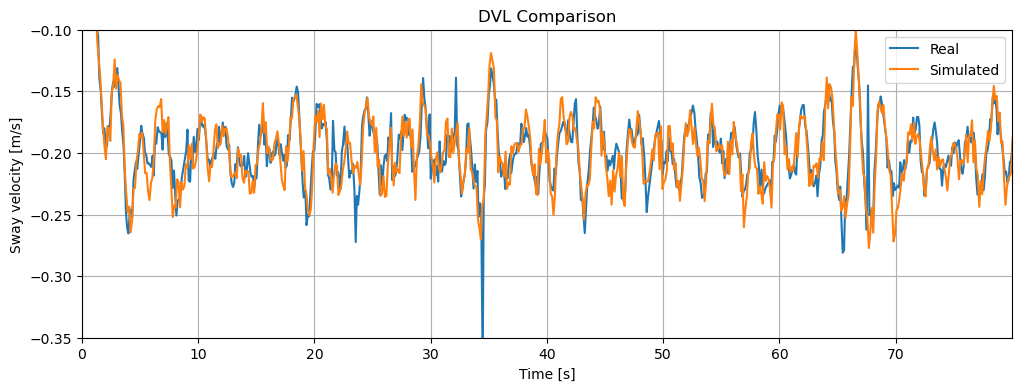

In [5]:
# Read csv
real_dvl_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")
sim_dvl_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")
sim_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")


# start fra t = 0
real_dvl_df["t"] -= real_dvl_df["t"][0]
t_real = real_dvl_df["t"].values

sim_dvl_df["t"] -= sim_dvl_df["t"][0]
sim_dvl_df = cut_dataframe(sim_dvl_df, 0, 80)
t_sim = sim_dvl_df["t"].values

sim_gt_df["t"] -= sim_gt_df["t"][0]
t_gt = sim_gt_df["t"].values


# Map to correct axis
vel_y = -real_dvl_df["velocity.x"].values

vel_y_sim = sim_dvl_df["velocity.y"].values

vel_y_gt = sim_gt_df["twist.twist.linear.y"].values

time_lag, t_start, t_end, rmse, correlation = compare_singals(t_real, t_sim, vel_y, vel_y_sim)


# PLOT
plt.figure(figsize=(12, 4))
plt.title("DVL Comparison")
plt.plot(t_real, vel_y, label="Real")
plt.plot(t_sim-time_lag, vel_y_sim, label="Simulated")
# plt.plot(t_gt-time_lag, vel_y_gt, label="Sim. Ground Truth", ls="-")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")
plt.legend()
plt.grid(True)

plt.xlim(t_start, t_end)
plt.ylim(-0.35, -0.1)

plt.show()

# Dvl Altitude

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:212: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


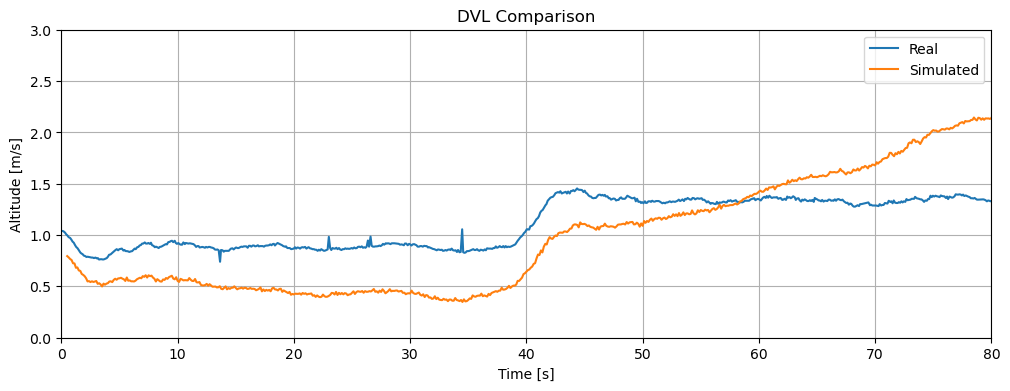

In [6]:
# Read csv
real_dvl_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")
sim_dvl_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")


# start fra t = 0
real_dvl_df["t"] -= real_dvl_df["t"][0]
t_real = real_dvl_df["t"].values

sim_dvl_df["t"] -= sim_dvl_df["t"][0]
sim_dvl_df = cut_dataframe(sim_dvl_df, 0, 80)
t_sim = sim_dvl_df["t"].values


# Map to correct axis
altitude_real = real_dvl_df["altitude"].values

altitude_sim = sim_dvl_df["altitude"].values


# time_lag, t_start, t_end, rmse, correlation = compare_singals(t_real, t_sim, altitude_real, altitude_sim)

# PLOT
plt.figure(figsize=(12, 4))
plt.title("DVL Comparison")
plt.plot(t_real, altitude_real, label="Real")
plt.plot(t_sim + 0.5, altitude_sim, label="Simulated")
plt.xlabel("Time [s]")
plt.ylabel("Altitude [m/s]")
plt.legend()
plt.grid(True)

plt.xlim(0, 80)
plt.ylim(0, 3)


plt.show()

# Depth

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:212: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


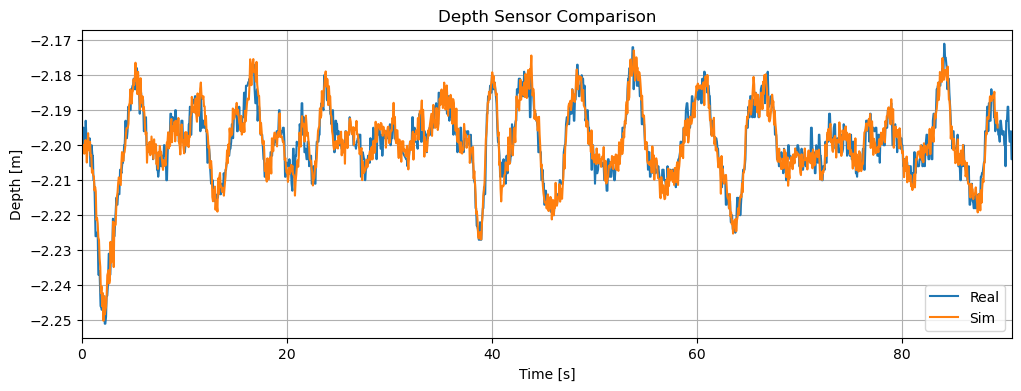

In [7]:
# Read csv
real_depth_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/depth_temperature")
sim_depth_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/pressure")
sim_depth_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")

# start fra t = 0
real_depth_df["t"] -= real_depth_df["t"][0]
t_real = real_depth_df["t"].values

sim_depth_df["t"] -= sim_depth_df["t"][0]
t_sim = sim_depth_df["t"].values


sim_depth_gt_df["t"] -= sim_depth_gt_df["t"][0]
t_gt = sim_depth_gt_df["t"].values


sim_depth_gt = sim_depth_gt_df["pose.pose.position.z"].values


RHO = 1031 # [kg/m^3]
g = 9.81

# get array of data
depth_real = real_depth_df["depth"].values
depth_real *= -1 # flip axis

depth_sim = (sim_depth_df["fluid_pressure"].values) / (RHO * g)


# Match mean values (depth differ slightly)
depth_sim -= depth_sim.mean()
depth_sim += depth_real.mean()


sim_depth_gt -= sim_depth_gt.mean()
sim_depth_gt += depth_real.mean()

time_lag, t_start, t_end, rmse, correlation = compare_singals(t_real, t_sim, depth_real, depth_sim)


# PLOT
plt.figure(figsize=(12, 4))
plt.title("Depth Sensor Comparison")
plt.plot(t_real, depth_real, label="Real")
plt.plot(t_sim - time_lag, depth_sim, label="Sim")
# plt.plot(t_gt - time_lag, sim_depth_gt, label="Ground truth")

plt.xlabel("Time [s]")
plt.ylabel("Depth [m]")
plt.legend()
plt.grid(True)

plt.xlim(t_start, t_end)
# plt.ylim(-0.35, -0.1)

plt.show()

# Estimate noise

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


20.535955516543844

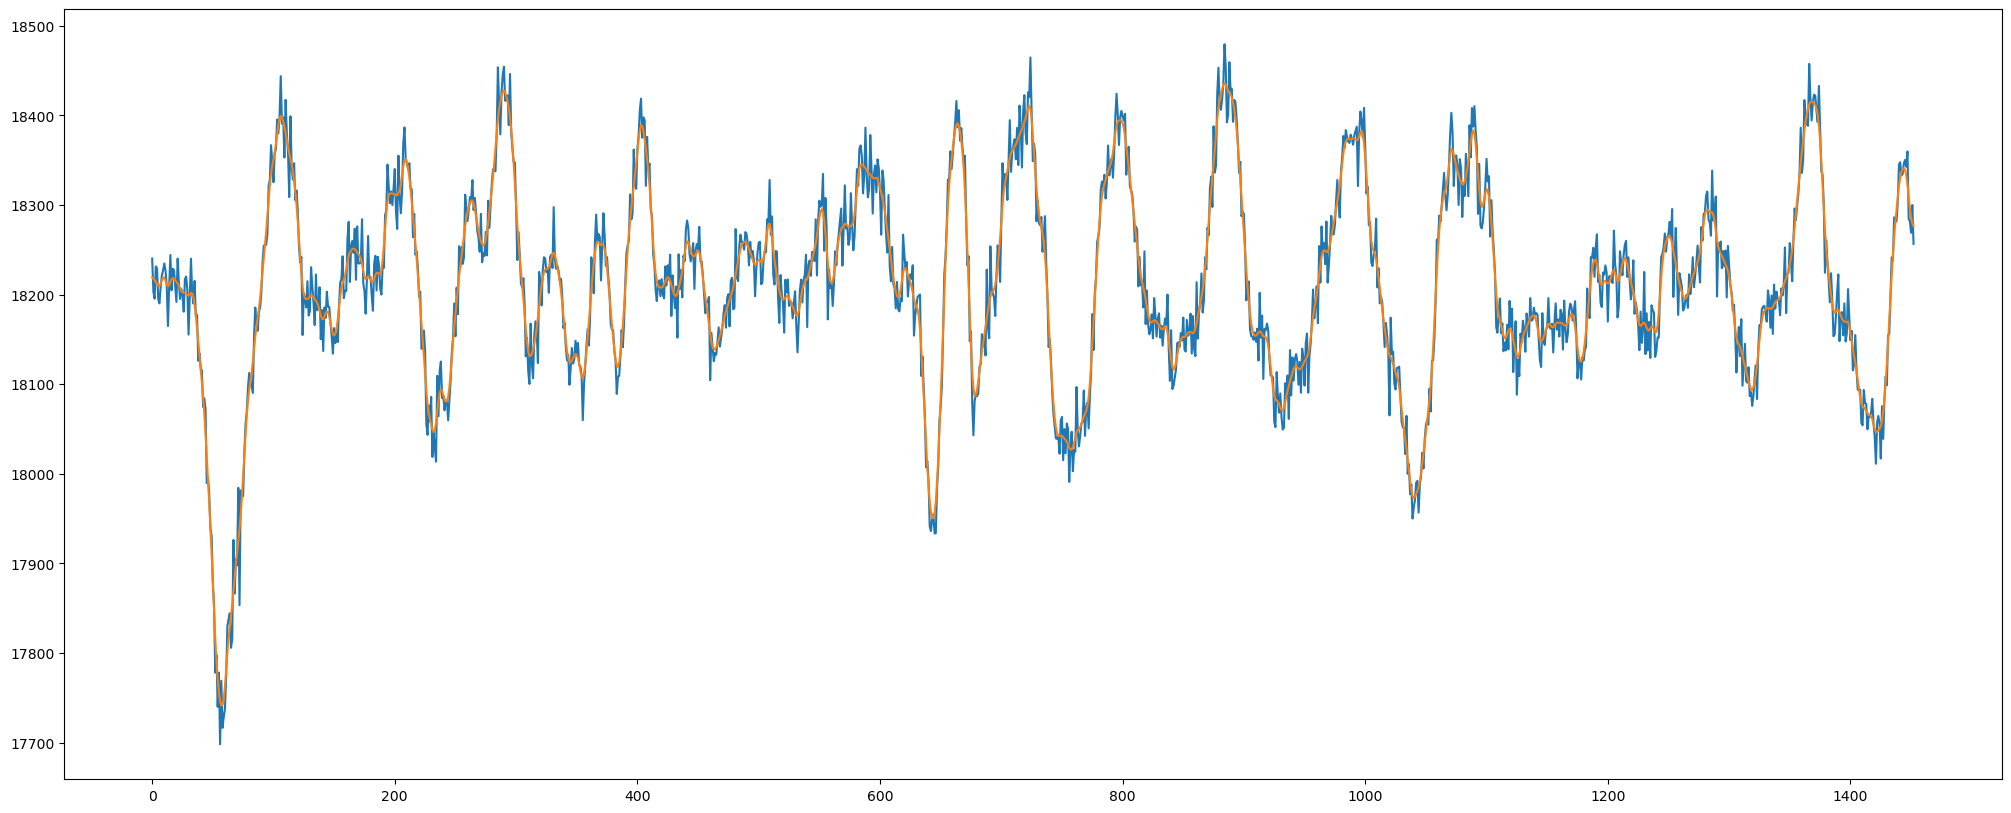

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def estimate_noise_std(data, smooth_sigma=2):
    """Estimer støyens standardavvik i en 1D-signalserie."""
    smooth = gaussian_filter1d(data, sigma=smooth_sigma)
    residual = data - smooth
    
    t = np.arange(0, len(smooth))
    plt.figure(figsize=(25, 10))
    plt.plot(t, data)
    plt.plot(t, smooth)

    return np.std(residual, ddof=1)

# estimate_noise_std(depth_real) * (RHO * g)
estimate_noise_std(sim_depth_df["fluid_pressure"].values)


# INS - Nucleus 1000

In [ ]:
bagdir = Path('/root/stonefish_ros2_ws/sintef_dataset/2024-08-20_16-34-34_data.bag')

with AnyReader([bagdir]) as reader:
    print('Topics and message types:')
    for c in sorted(reader.connections, key=lambda x: x.topic):
        print(f'{c.topic:45s}  {c.msgtype}')


NameError: name 'Path' is not defined

In [16]:
data = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation_position")
# data = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation")
data

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:212: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


,t,__msgtype__,header.__msgtype__,header.frame_id,header.seq,header.stamp.__msgtype__,header.stamp.nanosec,header.stamp.sec,pitch,roll,t_last_reset,time,x,y,yaw,z
0,1.724164e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,386,builtin_interfaces/msg/Time,565864086,1724164479,1.398418,-2.497854,1.724164e+09,1.687100e+09,0.002455,-0.036026,-0.811035,0.007918
1,1.724164e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,387,builtin_interfaces/msg/Time,801519155,1724164479,1.590327,-2.002819,1.724164e+09,1.687100e+09,0.010189,-0.051770,-0.632555,0.014073
2,1.724164e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,388,builtin_interfaces/msg/Time,6940126,1724164480,1.843149,-1.583715,1.724164e+09,1.687100e+09,0.025066,-0.064422,-0.610183,0.009308
3,1.724164e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,389,builtin_interfaces/msg/Time,222362518,1724164480,2.150046,-1.233694,1.724164e+09,1.687100e+09,0.047654,-0.073586,-0.764366,-0.002362
4,1.724164e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,390,builtin_interfaces/msg/Time,452746391,1724164480,2.295287,-0.836874,1.724164e+09,1.687100e+09,0.079026,-0.085261,-1.169754,-0.014252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,1.724165e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,809,builtin_interfaces/msg/Time,850400447,1724164571,58.060997,2.207453,1.724164e+09,1.687101e+09,-8.008355,-15.117502,-1.323664,-0.239923
424,1.724165e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,810,builtin_interfaces/msg/Time,63829421,1724164572,-0.130412,-0.888691,1.724164e+09,1.687101e+09,-0.003077,-0.017437,-0.025401,0.004656
425,1.724165e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,811,builtin_interfaces/msg/Time,300197362,1724164572,-0.966263,-1.943485,1.724164e+09,1.687101e+09,-0.012131,-0.038304,0.100897,0.006356
426,1.724165e+09,messages/msg/PlaneApproximationPosition,std_msgs/msg/Header,NaN,812,builtin_interfaces/msg/Time,503163576,1724164572,-1.681819,-2.484622,1.724164e+09,1.687101e+09,-0.017901,-0.052735,0.164732,-0.000975
